## Binary Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler,LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Data Loading and Checking!!!

In [2]:
df = pd.read_csv("new_train.csv")

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,227,4,999,0,nonexistent,no
1,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,202,2,999,1,failure,no
2,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,1148,1,999,0,nonexistent,yes
3,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,120,2,999,0,nonexistent,no
4,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,368,2,999,0,nonexistent,no


In [4]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
32945,28,services,single,high.school,no,yes,no,cellular,jul,tue,192,1,999,0,nonexistent,no
32946,52,technician,married,professional.course,no,yes,no,cellular,nov,fri,64,1,999,1,failure,no
32947,54,admin.,married,basic.9y,no,no,yes,cellular,jul,mon,131,4,999,0,nonexistent,no
32948,29,admin.,married,university.degree,no,no,no,telephone,may,fri,165,1,999,0,nonexistent,no
32949,35,admin.,married,university.degree,no,no,yes,telephone,jun,tue,544,3,999,0,nonexistent,no


In [5]:
df.describe()

,age,duration,campaign,pdays,previous
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,40.014112,258.127466,2.560607,962.052413,0.174719
std,10.403636,258.975917,2.752326,187.951096,0.499025
min,17.000000,0.000000,1.000000,0.000000,0.000000
25%,32.000000,103.000000,1.000000,999.000000,0.000000
50%,38.000000,180.000000,2.000000,999.000000,0.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          32950 non-null  int64 
 1   job          32950 non-null  object
 2   marital      32950 non-null  object
 3   education    32950 non-null  object
 4   default      32950 non-null  object
 5   housing      32950 non-null  object
 6   loan         32950 non-null  object
 7   contact      32950 non-null  object
 8   month        32950 non-null  object
 9   day_of_week  32950 non-null  object
 10  duration     32950 non-null  int64 
 11  campaign     32950 non-null  int64 
 12  pdays        32950 non-null  int64 
 13  previous     32950 non-null  int64 
 14  poutcome     32950 non-null  object
 15  y            32950 non-null  object
dtypes: int64(5), object(11)
memory usage: 4.0+ MB


In [7]:
df.isnull().sum()

age            0
job            0
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
y              0
dtype: int64

In [8]:
cat_cols = df.select_dtypes(include='object').columns
for cat_col in cat_cols:
    print('-'*80)
    print(f"Column Name: {cat_col}")
    print(f'Unique: {df[cat_col].unique()}')
    print(f'Col: {df[cat_col].value_counts()}')

--------------------------------------------------------------------------------
Column Name: job
Unique: ['blue-collar' 'entrepreneur' 'retired' 'admin.' 'student' 'services'
 'technician' 'self-employed' 'management' 'unemployed' 'unknown'
 'housemaid']
Col: job
admin.           8314
blue-collar      7441
technician       5400
services         3196
management       2345
retired          1366
entrepreneur     1160
self-employed    1099
housemaid         855
unemployed        798
student           711
unknown           265
Name: count, dtype: int64
--------------------------------------------------------------------------------
Column Name: marital
Unique: ['married' 'divorced' 'single' 'unknown']
Col: marital
married     19953
single       9257
divorced     3675
unknown        65
Name: count, dtype: int64
--------------------------------------------------------------------------------
Column Name: education
Unique: ['basic.9y' 'university.degree' 'basic.4y' 'high.school'
 'professiona

In [9]:
num_cols = df.select_dtypes(exclude='object').columns
for num_col in num_cols:
    print('-'*80)
    print(f"Column Name: {num_col}")
    print(f'Unique: {df[num_col].unique()}')
    print(f'Col: {df[num_col].value_counts()}')

--------------------------------------------------------------------------------
Column Name: age
Unique: [49 37 78 36 59 29 26 30 50 33 44 32 43 56 40 47 34 46 39 41 55 38 63 23
 48 53 35 51 71 58 21 45 25 77 28 52 80 57 22 60 27 24 31 42 54 81 64 79
 20 76 82 19 68 65 73 66 85 74 61 86 69 18 83 88 70 87 84 75 62 72 67 89
 17 91 98]
Col: age
31    1551
32    1474
33    1443
35    1417
34    1404
      ... 
17       3
89       2
87       1
91       1
98       1
Name: count, Length: 75, dtype: int64
--------------------------------------------------------------------------------
Column Name: duration
Unique: [ 227  202 1148 ... 1882 1666 1434]
Col: duration
90      147
124     139
136     138
85      137
97      133
       ... 
1720      1
1342      1
1233      1
1088      1
2372      1
Name: count, Length: 1467, dtype: int64
--------------------------------------------------------------------------------
Column Name: campaign
Unique: [ 4  2  1  5  9  3  7  6 13  8 12 10 19 11 31 17 16 

In [10]:
df[cat_cols].head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
0,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,nonexistent,no
1,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,failure,no
2,retired,married,basic.4y,no,no,no,cellular,jul,mon,nonexistent,yes
3,admin.,married,university.degree,no,yes,no,telephone,may,mon,nonexistent,no
4,retired,divorced,university.degree,no,no,no,cellular,jun,tue,nonexistent,no


In [11]:
df[num_cols].head()

,age,duration,campaign,pdays,previous
0,49,227,4,999,0
1,37,202,2,999,1
2,78,1148,1,999,0
3,36,120,2,999,0
4,59,368,2,999,0


### Data Cleaning!!!

In [12]:
df.drop(columns=['pdays','default','day_of_week'],inplace=True)
df.drop(df[df['marital'] =='unknown'].index,inplace=True)
df.drop(df[df['housing'] == 'unknown'].index, inplace=True)

In [13]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns
print(cat_cols)

Index(['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month',
       'poutcome', 'y'],
      dtype='object')


### Lets put on Label

In [ ]:
def la_encode(name):
    le = LabelEncoder()
    df[name+'_encode'] = le.fit_transform(df[name])
    # df = df.drop(name,axis=1)
    print("-"*60)
    print(f"Encoded column - {name}")

for cat_col in cat_cols:
    la_encode(cat_col)

------------------------------------------------------------
Encoded for :job
------------------------------------------------------------
Encoded for :marital
------------------------------------------------------------
Encoded for :education
------------------------------------------------------------
Encoded for :housing
------------------------------------------------------------
Encoded for :loan
------------------------------------------------------------
Encoded for :contact
------------------------------------------------------------
Encoded for :month
------------------------------------------------------------
Encoded for :poutcome
------------------------------------------------------------
Encoded for :y


In [16]:
df.head()

,age,job,marital,education,housing,loan,contact,month,duration,campaign,...,y,job_encode,marital_encode,education_encode,housing_encode,loan_encode,contact_encode,month_encode,poutcome_encode,y_encode
0,49,blue-collar,married,basic.9y,no,no,cellular,nov,227,4,...,no,1,1,2,0,0,0,7,1,0
1,37,entrepreneur,married,university.degree,no,no,telephone,nov,202,2,...,no,2,1,6,0,0,1,7,0,0
2,78,retired,married,basic.4y,no,no,cellular,jul,1148,1,...,yes,5,1,0,0,0,0,3,1,1
3,36,admin.,married,university.degree,yes,no,telephone,may,120,2,...,no,0,1,6,1,0,1,6,1,0
4,59,retired,divorced,university.degree,no,no,cellular,jun,368,2,...,no,5,0,6,0,0,0,4,1,0


In [17]:
df = df.drop(cat_cols,axis=1)

In [18]:
df.head()

,age,duration,campaign,previous,job_encode,marital_encode,education_encode,housing_encode,loan_encode,contact_encode,month_encode,poutcome_encode,y_encode
0,49,227,4,0,1,1,2,0,0,0,7,1,0
1,37,202,2,1,2,1,6,0,0,1,7,0,0
2,78,1148,1,0,5,1,0,0,0,0,3,1,1
3,36,120,2,0,0,1,6,1,0,1,6,1,0
4,59,368,2,0,5,0,6,0,0,0,4,1,0


In [19]:
df.rename(columns={'job_encode':'job','marital_encode':'marital','education_encode':'education', 'housing_encode':'housing','loan_encode':'loan','contact_encode':'contact','month_encode':'month','poutcome_encode':'poutcome','y_encode':'y'},inplace=True)

In [20]:
df.head()

,age,duration,campaign,previous,job,marital,education,housing,loan,contact,month,poutcome,y
0,49,227,4,0,1,1,2,0,0,0,7,1,0
1,37,202,2,1,2,1,6,0,0,1,7,0,0
2,78,1148,1,0,5,1,0,0,0,0,3,1,1
3,36,120,2,0,0,1,6,1,0,1,6,1,0
4,59,368,2,0,5,0,6,0,0,0,4,1,0


In [23]:
corr = df.corr()
corr

,age,duration,campaign,previous,job,marital,education,housing,loan,contact,month,poutcome,y
age,1.000000,-0.002066,0.003149,0.021516,0.000266,-0.396311,-0.115586,-0.002963,-0.004097,0.006140,-0.027146,0.021161,0.028141
duration,-0.002066,1.000000,-0.075991,0.020649,-0.009222,0.008657,-0.017479,-0.009533,0.004168,-0.023883,0.002262,0.032263,0.400091
campaign,0.003149,-0.075991,1.000000,-0.080079,-0.008248,-0.003483,-0.001702,-0.013563,0.006031,0.075068,-0.062076,0.032777,-0.064726
previous,0.021516,0.020649,-0.080079,1.000000,0.022655,0.041142,0.041571,0.028000,-0.001991,-0.211374,0.101674,-0.310674,0.227959
job,0.000266,-0.009222,-0.008248,0.022655,1.000000,0.028349,0.130755,0.008241,-0.012765,-0.024339,-0.028326,0.012796,0.025201
marital,-0.396311,0.008657,-0.003483,0.041142,0.028349,1.000000,0.110413,0.018925,0.007746,-0.055892,-0.006838,0.002271,0.048383
education,-0.115586,-0.017479,-0.001702,0.041571,0.130755,0.110413,1.000000,0.023746,0.008735,-0.103217,-0.084157,0.017284,0.059832
housing,-0.002963,-0.009533,-0.013563,0.028000,0.008241,0.018925,0.023746,1.000000,0.046454,-0.083829,-0.018693,-0.014908,0.010052
loan,-0.004097,0.004168,0.006031,-0.001991,-0.012765,0.007746,0.008735,0.046454,1.000000,-0.013355,-0.007949,-0.003003,-0.000268
contact,0.006140,-0.023883,0.075068,-0.211374,-0.024339,-0.055892,-0.103217,-0.083829,-0.013355,1.000000,0.275568,0.120065,-0.141297


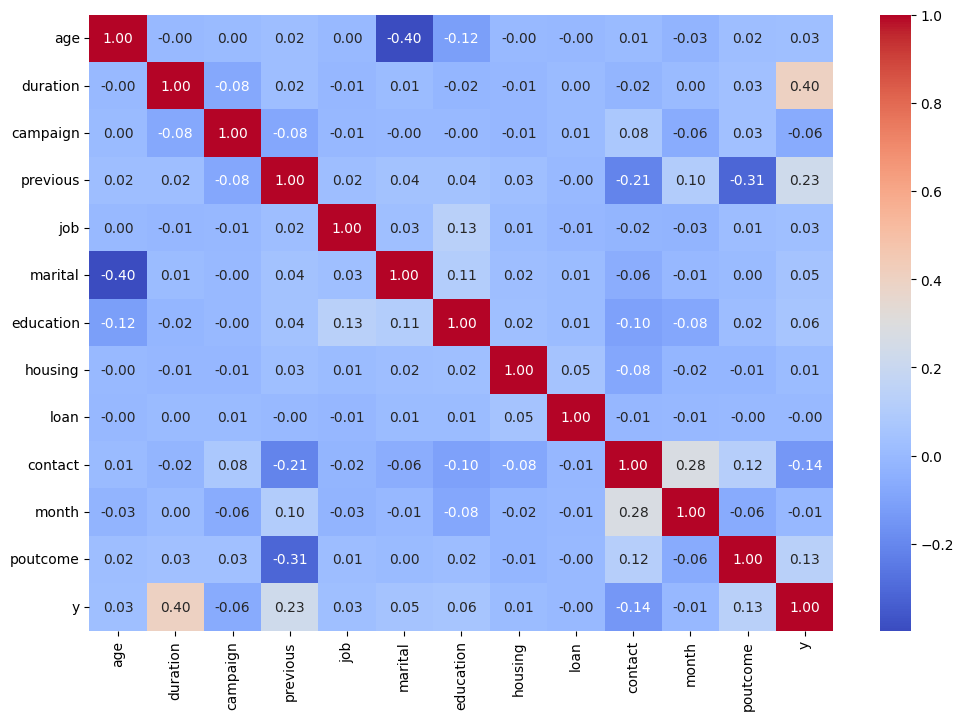

In [24]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt='0.2f',  cmap="coolwarm", cbar=True)
plt.show()

### When Data is cooked, You begin Eating.... I mean consuming

In [25]:
X = df.drop('y',axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
print("Train class distribution:")
print(np.unique(y_train, return_counts=True))

print("Test class distribution:")
print(np.unique(y_test, return_counts=True))

Train class distribution:
(array([0, 1]), array([22783,  2889]))
Test class distribution:
(array([0, 1]), array([5696,  722]))
